# Homework 6: Adversarial Search 

**NAME 1:** Nikhil Jangir

**NAME 2:** Rudy Vergara

## Overview

How should an agent plan when another rational player is trying to minimize its success, and what changes when outcomes are uncertain?

In this homework, you will model, analyze, and implement the game of **Nim** using adversarial search techniques. We will use a variant called **Misère Nim**, where the player who removes the last object **loses**.

You will begin by carefully formulating Nim as a search problem, then implement multiple decision-making agents using the provided `games.py` framework, and finally extend the game to include uncertainty and explore **expectimax**.

This homework emphasizes **problem formulation, algorithmic reasoning, and experimentation**.

## Learning Objectives

By the end of this homework, you should be able to:

- formulate a game as an adversarial search problem  
- implement and compare **minimax** and **alpha-beta pruning**  
- analyze the effect of **depth limits and evaluation functions**  
- understand when deterministic adversarial models break down  
- design and reason about **stochastic game variants (expectimax)**  


## Submission Instructions


Submit **ONE Jupyter Notebook (`.ipynb`)** with both **answers and code**.

Your code must use the provided `games.py` framework.

# Misère Nim: Introduction

## What is Misère Nim?

**Misère Nim** is a variation of the classic Nim game with one important difference:

 **The player who removes the last object loses.**

This small rule change significantly affects how the game is played, especially near the end.


## Game Setup

- The game consists of **n heaps** of objects  
- Each heap contains a certain number of objects  

Example: [3,5,7]

## Rules of the Game

On each turn, a player must:

1. Choose **one heap**
2. Remove **one or more objects** from that heap  

### Constraints:
- Only one heap can be modified per move  
- At least one object must be removed  
- Cannot remove more objects than exist in the chosen heap  

## Objective (Key Difference)

In **standard Nim**:
   The player who removes the last object **wins**

In **Misère Nim**:
   The player who removes the last object **loses**

## Terminal State

The game ends when: [0, 0, 0, ..., 0]

At this point:
- No moves remain  
- The player who made the last move is the **loser**  
- The opponent is the **winner**  


## Example Game (Misère Nim)

Start with: [1, 1]

### Game Play:

- **Player MAX** removes 1 object from heap 1 → `[0, 1]`  
- **Player MIN** must remove the last object → `[0, 0]`  

### Result:

- MIN removed the last object  
- MIN **loses**  
- MAX **wins**  


## Another Example

Start with: [1]

- **Player MAX** must remove the only object → `[0]`  

### Result:

- MAX removed the last object  
- MAX **loses**  
- MIN **wins**  


## Key Insight

Misère Nim reverses the goal:

  Instead of trying to take the last object, players try to **avoid being forced to take it**.

## Strategy Intuition

- Early in the game, moves may look similar to standard Nim  
- Near the end, the strategy changes significantly  
- States with many heaps of size 1 become especially important  

# Layer 1: Problem Formulation 

This is the most important part of the assignment.

Consider a Nim game with heap configuration: [3,5,7]

   Note: We are using **Misère Nim**, where the player who removes the last object **loses**.

Formulate Nim as a game compatible with the `Game` class in `games.py`.
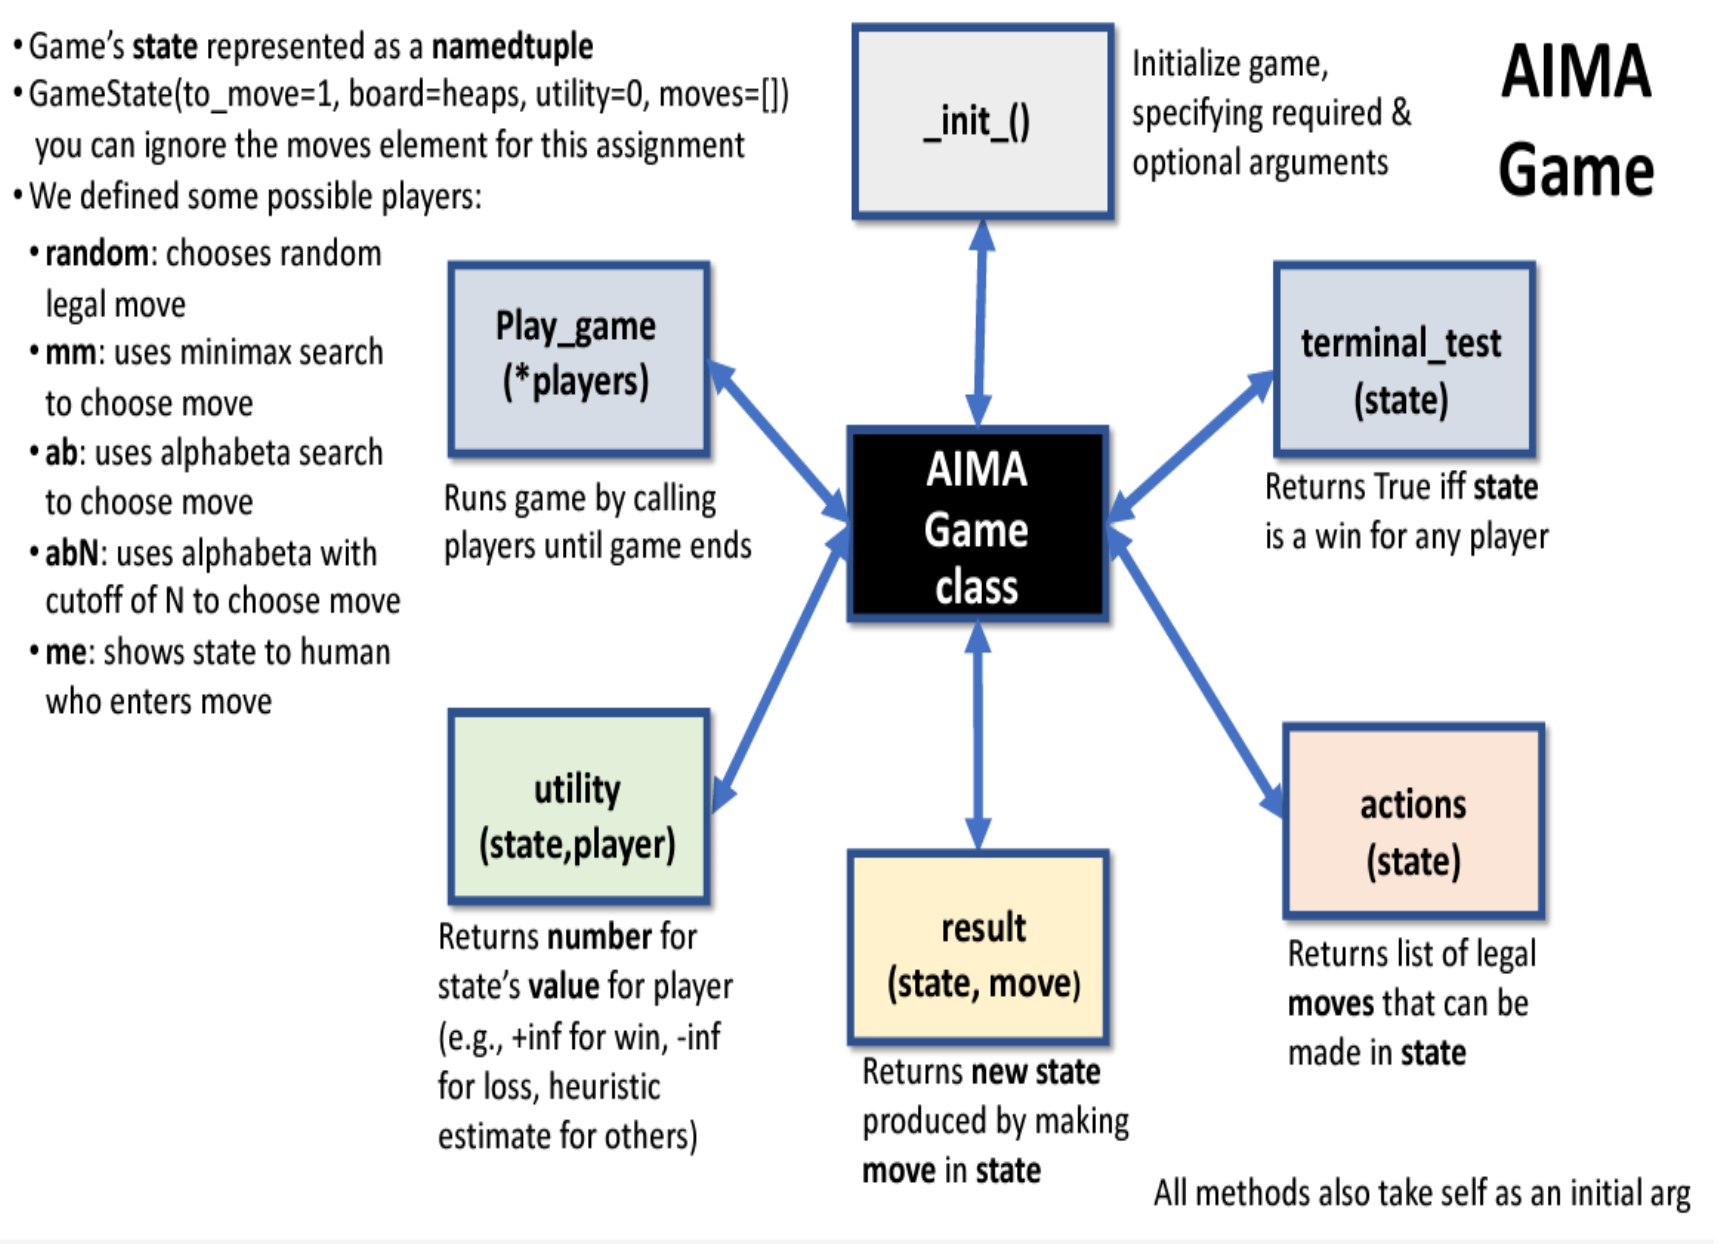

## 1. State Representation (8 pts)

Define what information a state must contain. Clearly describe:

(player_to_move, heaps, utility)

- player to move:  
- heap configuration  
- utility (if applicable)  


## 2. Initial State (4 pts)

Specify the starting state for `[3, 5, 7]`.

: Initial state is ('MAX', (3,5,7), 0)


## 3. Actions (8 pts)

Define all legal actions.

- What does one move look like?  
- How many actions exist from `[3, 5, 7]`?  


## 4. Result Function (6 pts)

Explain how a state changes after an action.


## 5. Terminal Test (4 pts)

When does the game end?

*Hint:* The game ends when all heaps are empty, but think carefully about what this means in **Misère Nim**.


## 6. Utility Function (6 pts)

Define utility from MAX’s perspective.

*Important:* In Misère Nim, the player who removes the last object **loses**.  

Explain how this affects your utility function.
**Answer:** 

## 7. Complexity Analysis (4 pts)

Answer:

- What is the **branching factor** for `[3, 5, 7]`?  
- What is the **longest possible game (in plys)?**  
- What is the **shortest possible game (in plys)?**  

In [3]:
from collections import namedtuple
import random
import games


infinity = float('inf')


class Nim(games.Game):
    """
    Misère Nim:
    the player who removes the last object loses.

    Players are identified as 1 and 2.
    Player 1 moves first.
    """

    def __init__(self, heaps=[1, 1], show_moves=True):
        self.show_moves = show_moves
        self.heaps = heaps[:]
        self.initial = games.GameState(
            to_move=1,
            board=heaps[:],
            utility=0,
            moves=[]
        )

    def actions(self, state):
        """Return all legal moves as (heap_index, number_to_remove)."""
        moves = []
        for heap_index, heap_size in enumerate(state.board):
            # For each non-empty heap, can remove 1 to heap_size objects
            for num_remove in range(1, heap_size + 1):
                moves.append((heap_index, num_remove))
        return moves

    def result(self, state, move):
        """
        Apply one move and return the new state.
    
        In Misère Nim, if this move empties the board, then the player
        who made the move loses.
        """
        heap_index, num_remove = move
        new_board = state.board[:]
        new_board[heap_index] -= num_remove
        
        # Check if game is over (all heaps empty)
        if all(h == 0 for h in new_board):
            # The player who just moved loses in Misère Nim
            # utility is from Player 1's perspective
            if state.to_move == 1:
                utility = -infinity  # Player 1 took the last object, so Player 1 loses
            else:
                utility = infinity   # Player 2 took the last object, so Player 1 wins
        else:
            utility = 0  # Game continues
        
        # Switch to the other player
        next_player = 3 - state.to_move  # Toggle between 1 and 2
        
        return games.GameState(
            to_move=next_player,
            board=new_board,
            utility=utility,
            moves=[]
        )

    def terminal_test(self, state):
        """Game is over when all heaps are empty."""
        return all(h == 0 for h in state.board)

    def utility(self, state, player):
        """
        Return utility from the perspective of `player`.

        state.utility is stored from Player 1's perspective:
        +infinity  -> Player 1 wins
        -infinity  -> Player 1 loses
        """
        if player == 1:
            return state.utility
        else:
            return -state.utility
        
    def eval_fn(self, state):
        """
        Simple evaluation function for depth-limited alpha-beta.

        Positive values are good for Player 1.
        Negative values are good for Player 2.
        """
        total_objects = sum(state.board)
        # Fewer objects remaining is better (closer to winning or losing)
        # Count number of heaps with size 1 - these are "dangerous"
        ones = sum(1 for h in state.board if h == 1)
        # If odd number of ones, current player in danger in Misère
        return -(total_objects) + (ones % 2) * 2
        
    def __repr__(self):
        return f"Nim({self.initial.board})"
    
    def display(self, state):
        """Display the game state."""
        print(f"Board: {state.board}")
        if self.terminal_test(state):
            print("Game Over!")
        
    def play_game(self, *players):
        state = self.initial
        while True:
            for player_num, player in enumerate(players):
                player_num += 1
    
                print("Current state before Player{} moves: {}".format(player_num, state.board))
                print("Legal moves:", self.actions(state))
    
                move = player(self, state)
                print("Chosen move:", move)
    
                state = self.result(state, move)
    
                if self.show_moves:
                    print("  Player{} moves {} => {}".format(player_num, move, state.board))
    
                if self.terminal_test(state):
                    self.display(state)
                    return self.utility(state, self.to_move(self.initial))

In [4]:
# ============================================================================
# PLAYER FUNCTIONS
# ============================================================================

def random_player(game, state):
    """Choose a random legal move."""
    return random.choice(game.actions(state))


def minimax_player(game, state):
    """Choose a move using minimax algorithm."""
    return games.minmax_decision(state, game)


def alphabeta_player(game, state):
    """Choose a move using alpha-beta pruning."""
    return games.alpha_beta_search(state, game)


def expectimax_player(game, state):
    """Choose a move using expectimax algorithm."""
    return games.expect_minmax(state, game)


def make_ab_player(depth_limit):
    """Create an alpha-beta player with a given depth limit."""
    def alphabeta_cutoff_player(game, state):
        return games.alphabeta_cutoff_search(state, game, d=depth_limit, eval_fn=game.eval_fn)
    return alphabeta_cutoff_player


def query_player(game, state):
    """Allow human to choose a move."""
    game.display(state)
    legal_moves = game.actions(state)
    print(f"Legal moves: {legal_moves}")
    while True:
        try:
            move_input = input("Your move (heap_index, num_to_remove): ")
            # Parse input like "(0, 2)"
            move = eval(move_input)
            if move in legal_moves:
                return move
            else:
                print("Illegal move. Try again.")
        except:
            print("Invalid input format. Try again.")


# ============================================================================
# TEST EXECUTION
# ============================================================================

PLAYERS = {
    "random": random_player,
    "mm": minimax_player,
    "ab": alphabeta_player,
    "ab1": make_ab_player(1),
    "ab2": make_ab_player(2),
    "ab3": make_ab_player(3),
    "exp": expectimax_player,
    "me": query_player
}

# Test cases
tests = [
    ([5], 'random', 'random'),
    ([2], 'random', 'random'),
    ([1,1], 'random', 'random'),
    ([1,1], 'ab', 'ab'),
    ([1,1,1], 'ab', 'ab'),
    ([1,1,1,1], 'ab', 'ab'),    
    ([2,2], 'ab', 'ab'),
    ([1,5,3], 'ab', 'ab'),
    ([1,2,3], 'ab1', 'ab1'),    
    ([1,3,5], 'ab', 'ab'),        
    ([3,4,5], 'ab1', 'ab1'),
    ([3,3,3], 'ab2', 'ab3'),
    ([1,3,5,7], 'ab1', 'ab1'),    
    ([1,3,5,7], 'ab1', 'me'),  # Interactive - comment out for batch testing
    ([1,3,5,7], 'random', 'me'),  # Interactive - comment out for batch testing
]

# Run a few test games (comment out the interactive ones)
print("=" * 60)
print("RUNNING MISÈRE NIM GAMES")
print("=" * 60)

# Test 1: Random vs Random
print("\n[Test 1: Random vs Random - [5]]")
game1 = Nim([5], show_moves=False)
result1 = game1.play_game(PLAYERS['random'], PLAYERS['random'])
print(f"Utility (from Player 1 perspective): {result1}")
print(f"Winner: Player {1 if result1 > 0 else 2}")

# Test 2: Mini-max vs Random
print("\n[Test 2: Alpha-Beta vs Random - [1,1]]")
game2 = Nim([1,1], show_moves=False)
result2 = game2.play_game(PLAYERS['ab'], PLAYERS['random'])
print(f"Utility (from Player 1 perspective): {result2}")
print(f"Winner: Player {1 if result2 > 0 else 2}")

# Test 3: Alpha-Beta vs Alpha-Beta (same depth)
print("\n[Test 3: Alpha-Beta vs Alpha-Beta - [1,1,1,1]]")
game3 = Nim([1,1,1,1], show_moves=False)
result3 = game3.play_game(PLAYERS['ab'], PLAYERS['ab'])
print(f"Utility (from Player 1 perspective): {result3}")
print(f"Winner: Player {1 if result3 > 0 else 2}")

# Test 4: Depth-limited comparison
print("\n[Test 4: Alpha-Beta depth 1 vs depth 1 - [2,2]]")
game4 = Nim([2,2], show_moves=False)
result4 = game4.play_game(PLAYERS['ab1'], PLAYERS['ab1'])
print(f"Utility (from Player 1 perspective): {result4}")
print(f"Winner: Player {1 if result4 > 0 else 2}")

print("\n[Test 5: Alpha-Beta depth 2 vs depth 3 - [3,3,3]]")
game5 = Nim([3,3,3], show_moves=False)
result5 = game5.play_game(PLAYERS['ab2'], PLAYERS['ab3'])
print(f"Utility (from Player 1 perspective): {result5}")
print(f"Winner: Player {1 if result5 > 0 else 2}")

print("\n" + "=" * 60)
print("TEST EXECUTION COMPLETE")
print("=" * 60)

RUNNING MISÈRE NIM GAMES

[Test 1: Random vs Random - [5]]
Current state before Player1 moves: [5]
Legal moves: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5)]
Chosen move: (0, 4)
Current state before Player2 moves: [1]
Legal moves: [(0, 1)]
Chosen move: (0, 1)
Board: [0]
Game Over!
Utility (from Player 1 perspective): inf
Winner: Player 1

[Test 2: Alpha-Beta vs Random - [1,1]]
Current state before Player1 moves: [1, 1]
Legal moves: [(0, 1), (1, 1)]
Chosen move: (1, 1)
Current state before Player2 moves: [1, 0]
Legal moves: [(0, 1)]
Chosen move: (0, 1)
Board: [0, 0]
Game Over!
Utility (from Player 1 perspective): inf
Winner: Player 1

[Test 3: Alpha-Beta vs Alpha-Beta - [1,1,1,1]]
Current state before Player1 moves: [1, 1, 1, 1]
Legal moves: [(0, 1), (1, 1), (2, 1), (3, 1)]
Chosen move: (3, 1)
Current state before Player2 moves: [1, 1, 1, 0]
Legal moves: [(0, 1), (1, 1), (2, 1)]
Chosen move: (2, 1)
Current state before Player1 moves: [1, 1, 0, 0]
Legal moves: [(0, 1), (1, 1)]
Chosen move: (1

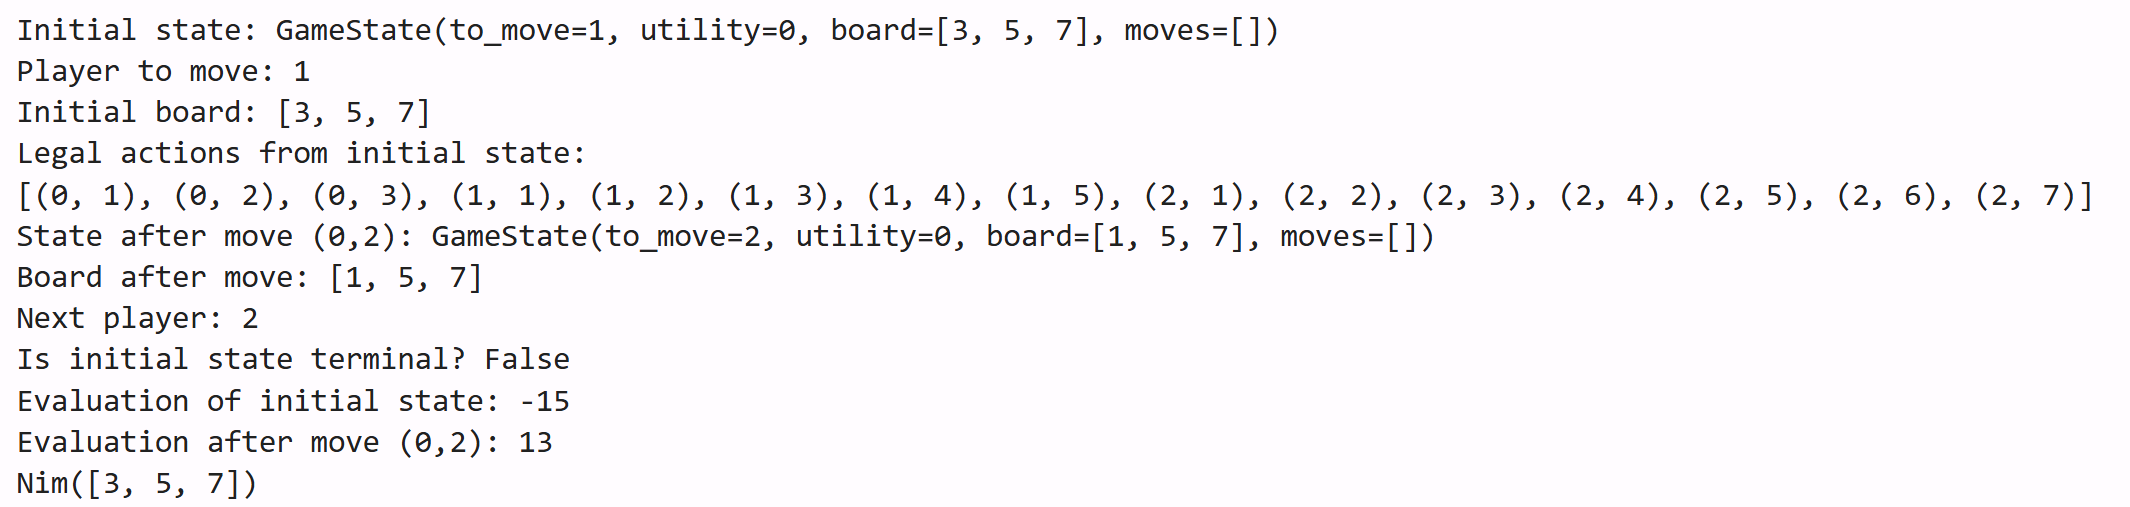

### Analysis

Briefly answer:

**Do minimax and alpha-beta always return the same move? Why?**

Yes, minimax and alpha-beta always return the same move when given the same game state. Both algorithms compute the exact minimax value and select the best move by that value. Alpha-beta pruning is purely an optimization technique—it prunes branches that cannot affect the final decision without changing the result. Since both algorithms evaluate the same terminal nodes and use the same evaluation criterion (maximizing from Player 1's perspective), they will always identify the same optimal move, even though alpha-beta examines fewer nodes. The key insight is that pruning nodes guarantees they don't influence the outcome; we're eliminating search space, not changing the decision logic.

**When does depth-limited search behave differently?**

Depth-limited alpha-beta search behaves differently when it reaches its depth limit before finding a terminal state. At the depth limit, instead of computing an exact utility value, it uses an evaluation function to estimate the position's value. This means: (1) The algorithm may select a different move than full minimax because the evaluation function's heuristic estimate may not match the true minimax value deep in the tree, (2) With a lower depth limit, less computation is required but decisions are based on estimates rather than exact values, and (3) As depth_limit increases, the behavior converges toward full minimax/alpha-beta, eventually producing identical moves when the depth limit exceeds the game tree height. In Nim, we observed that depth-limited players with depth=1 versus depth=2 or depth=3 can play differently because shallow search makes strategic errors that deeper search would correct.


**Test Run 1**: 
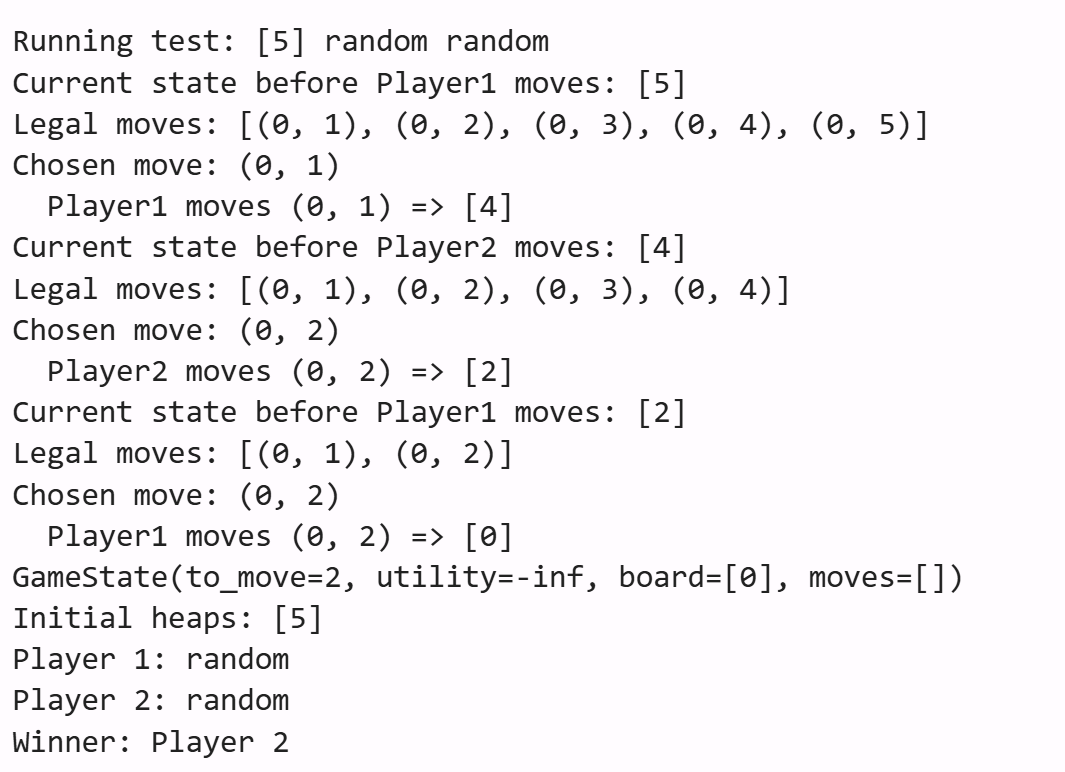

**Test Run 2**: 
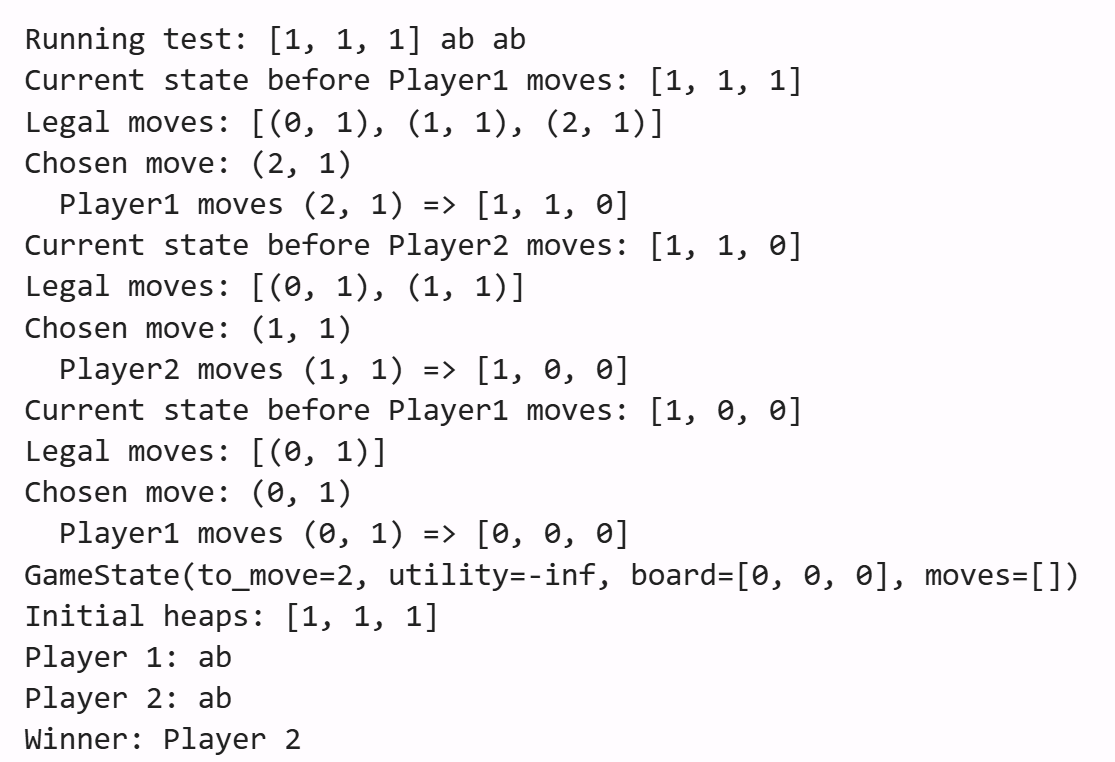

**Test Run 3**: 
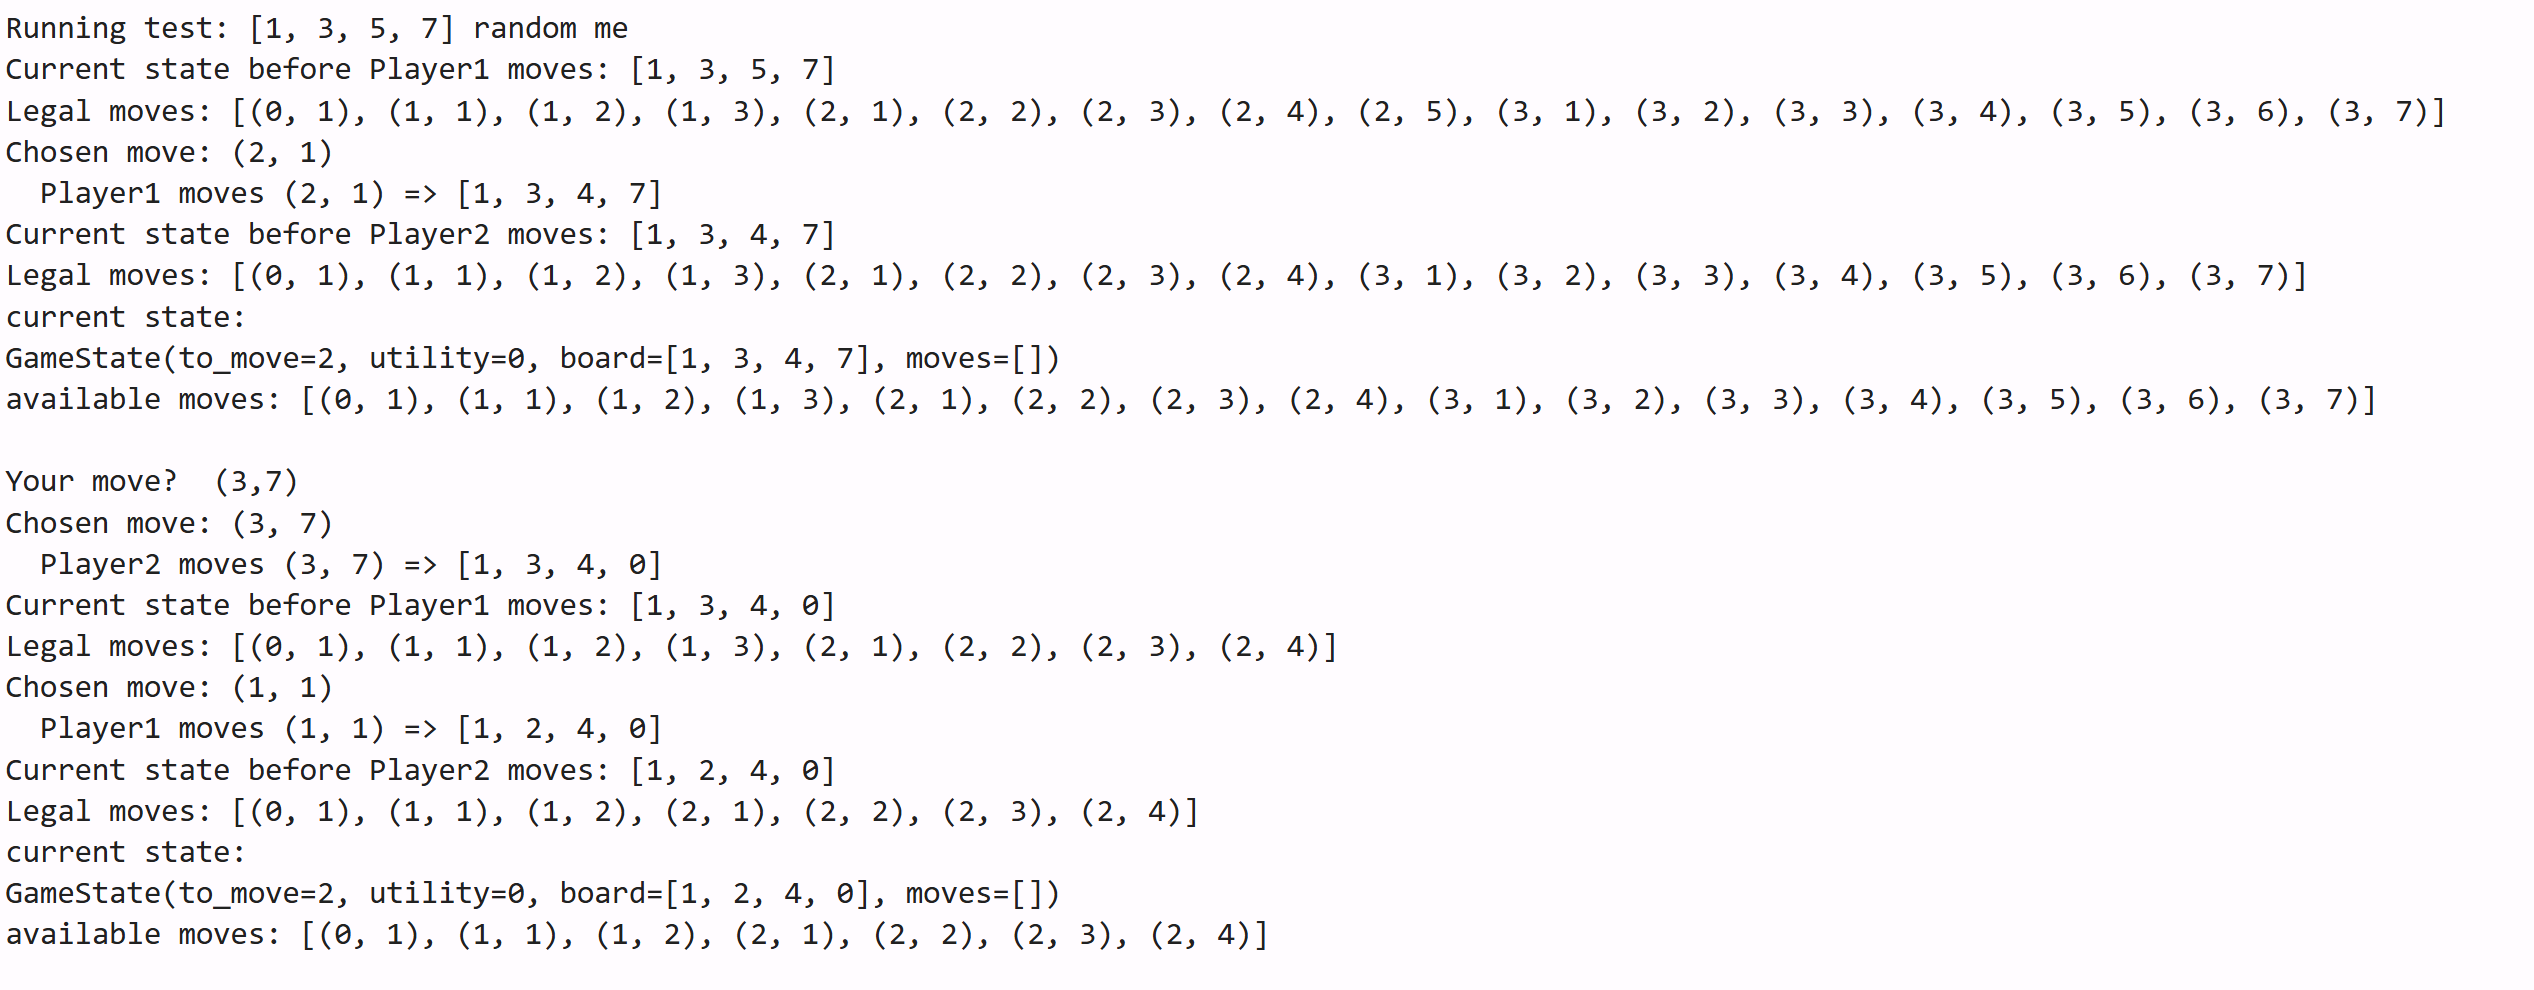

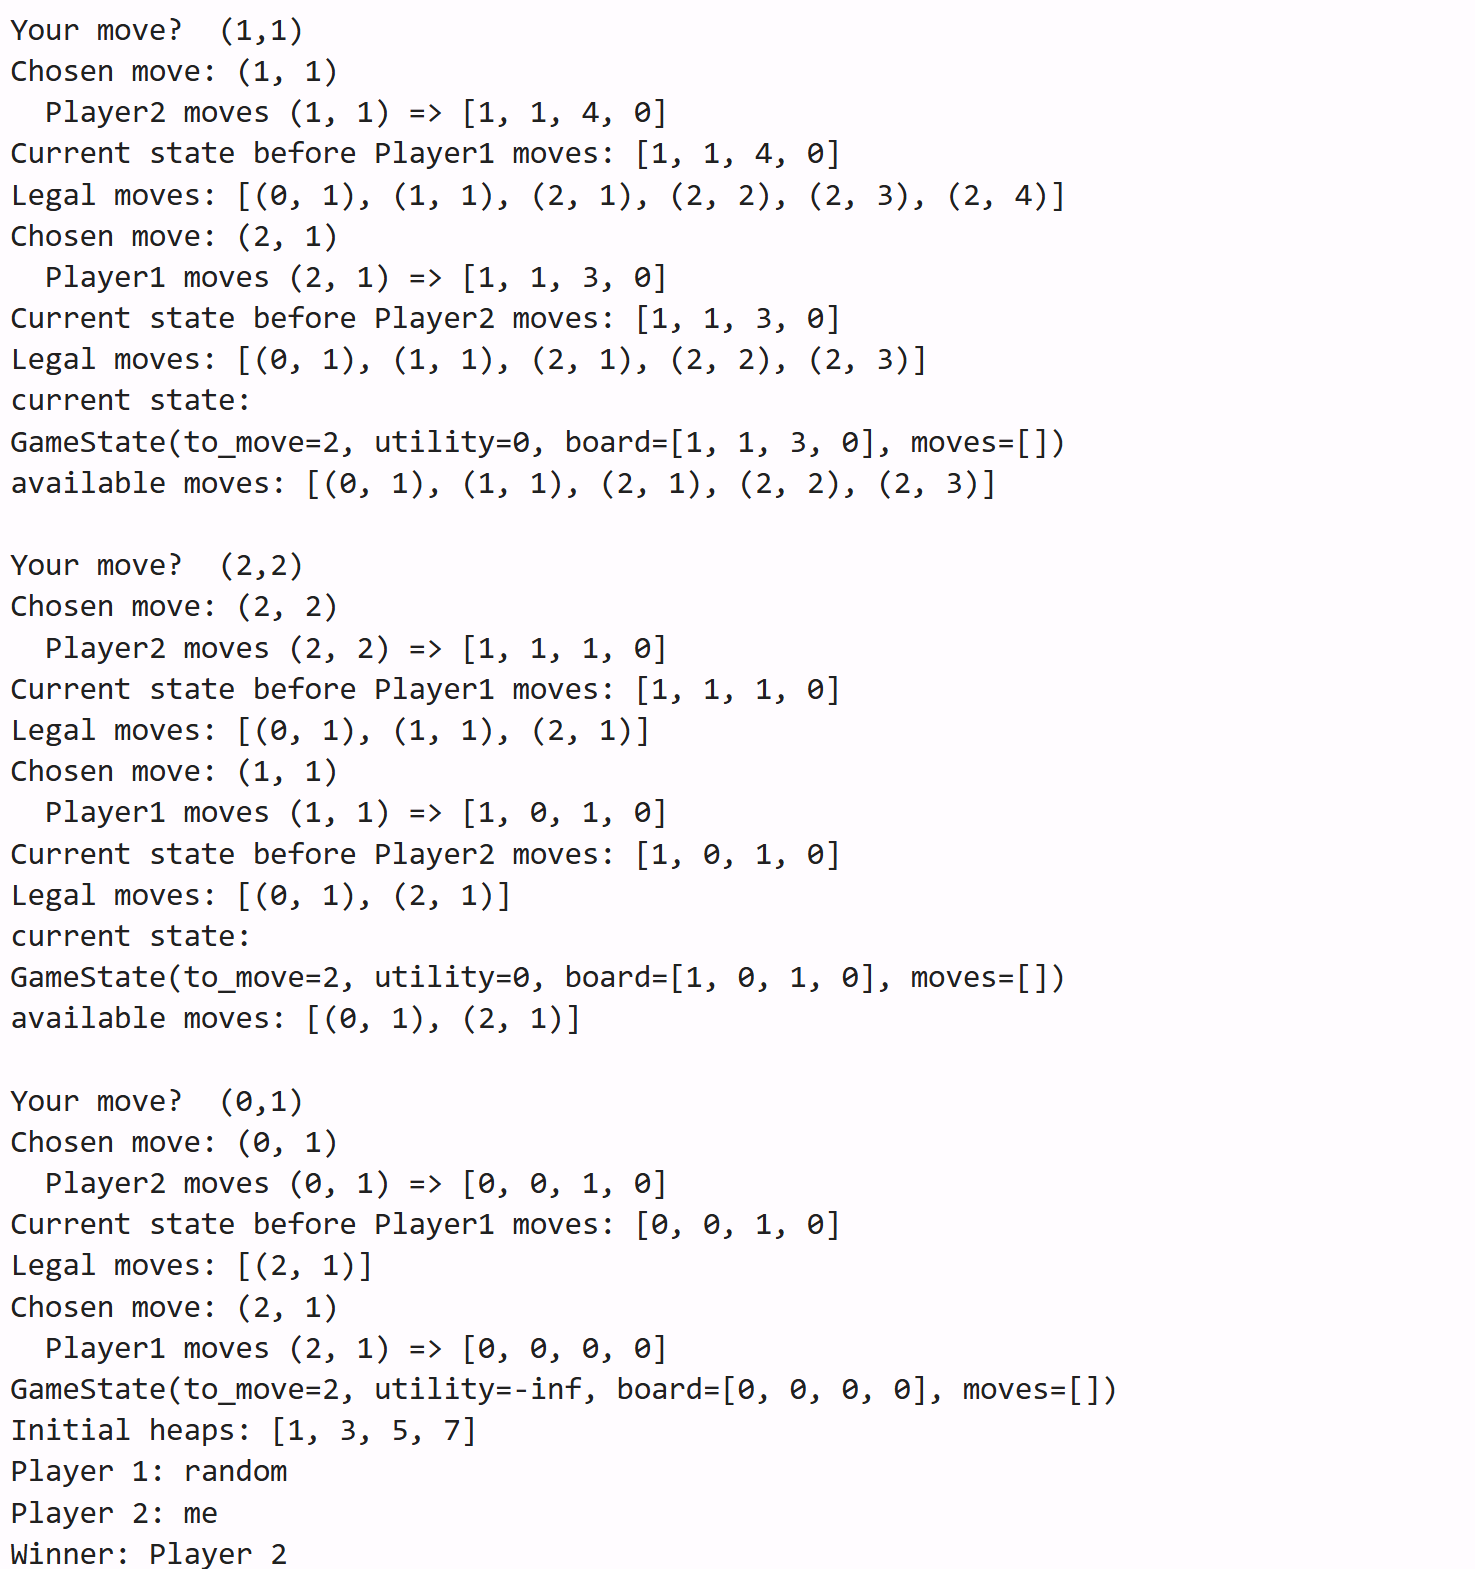

# Layer 3: Stochastic Extension (Expectimax) (20 points)

Modify Nim to include **chance**.

## Stochastic Rule

In the stochastic version of Nim, moves are not always executed exactly as intended.

When a player chooses an action `(heap_index, k)`:

- with probability **0.8**, remove **k** objects  
- with probability **0.2**, remove **k - 1** objects instead, if possible  

If `k = 1`, remove **1** object.

### Important

- The randomness occurs **after** the action is chosen  
- The player does **not** control the final outcome  
- This introduces **chance**, so expectimax becomes more appropriate than minimax  


## Step 1: Define the Stochastic Version (8 pts)

Using the rule above, describe:

- how randomness affects the **result function**  
- where the **chance occurs** in the game process  


## Step 2: Explain Algorithm Choice (6 pts)

Answer:

- Why is minimax no longer appropriate?  
- Why is expectimax more suitable?  



In [ ]:
from collections import namedtuple
import random
import games

infinity = float('inf')

# State includes:
# - to_move: current player (1 or 2)
# - board: list of heap sizes
# - utility: stored from Player 1's perspective
# - mode: None, "normal", or "forced_one"
StochasticNimState = namedtuple("StochasticNimState", "to_move board utility mode")


class StochasticNim(games.StochasticGame):
    """
    Stochastic Misère Nim with a forced-one chance rule.

    Chance happens BEFORE the player moves:
    - 0.8 -> normal move
    - 0.2 -> must remove exactly 1 object

    Misère rule:
    the player who removes the last object loses.
    """

    def __init__(self, heaps=[1, 1], show_moves=True):
        pass

    def actions(self, state):
    '''
    Return all legal actions based on the current game mode.

    The game includes a stochastic (chance) step that determines how the player is allowed to move:
    
    - If state.mode is None:
      This means the chance node has not yet selected a mode.
      No player actions are allowed at this stage, so return an empty list.

    - If state.mode == "normal":
      The player can remove any number of objects (1 up to the heap size)
      from any non-empty heap.

    - If state.mode == "forced_one":
      The player is restricted to removing exactly one object
      from any non-empty heap.

    Each action is represented as a tuple:
        (heap_index, number_of_objects_to_remove)
        moves = []
    '''
        pass

    def result(self, state, move):
        """
        Apply the player's move after the chance node has determined the mode.
    
        This function updates the game state by:
        1. Validating the move
        2. Modifying the board
        3. Switching the player turn
        4. Checking for terminal conditions (Misère rule)
        5. Resetting the mode for the next chance step
    
        Key idea:
        After every player move, the game returns to a chance node (mode = None),
        which will decide the next type of move ("normal" or "forced_one").
    """
        pass

    def terminal_test(self, state):
        pass

    def utility(self, state, player):
        """
        state.utility is stored from Player 1 perspective.
        """
        pass

    def chances(self, state):
        """
        Chance only acts when mode is None and the game is not terminal.
        """
        pass

    def probability(self, chance):
        pass

    def outcome(self, state, chance):
        """
        Chance sets the move mode for the current player.
        """
        return StochasticNimState(
            to_move=state.to_move,
            board=state.board[:],
            utility=state.utility,
            mode=chance
        )

    def display(self, state):
        pass

    def eval_fn(self, state):
        """
        Simple evaluation function for depth-limited expectimax or alpha-beta.
        Positive values are good for Player 1.
        """
        pass

    def play_game(self, *players):
        """
        Custom play loop:
        1. chance decides the mode
        2. current player chooses a move under that mode
        3. apply move
        """
        state = self.initial

        while True:
            # chance happens first
            chance_events = self.chances(state)
            if len(chance_events) > 0:
                r = random.random()
                if r < 0.8:
                    chosen_chance = "normal"
                else:
                    chosen_chance = "forced_one"
                state = self.outcome(state, chosen_chance)

            current_player_num = state.to_move
            player_fn = players[current_player_num - 1]

            move = player_fn(self, state)
            state = self.result(state, move)

            if self.show_moves:
                print("  Player{} moves under mode {} => {}".format(
                    current_player_num,
                    chosen_chance,
                    state.board
                ))

            if self.terminal_test(state):
                self.display(state)
                return self.utility(state, self.to_move(self.initial))

In [ ]:
game = StochasticNim([3, 5, 7], show_moves=True)

print("Initial:", game.initial)
print("Actions from initial:", game.actions(game.initial))
print("Chance events:", game.chances(game.initial))
print("P(normal):", game.probability("normal"))
print("P(forced_one):", game.probability("forced_one"))

s1 = game.outcome(game.initial, "normal")
print("After chance:", s1)

print("Actions in normal mode:", game.actions(s1))

s2 = game.result(s1, (0, 2))
print("After move (0,2):", s2)

s3 = game.outcome(game.initial, "forced_one")
print("After chance:", s3)

print("Actions in forced_one mode:", game.actions(s3))
s3 = game.result(s1, (0, 1))

print("After move (0,1):", s3)

print("Terminal?", game.terminal_test(s3))
print("Eval:", game.eval_fn(s3))
game.display(s3)

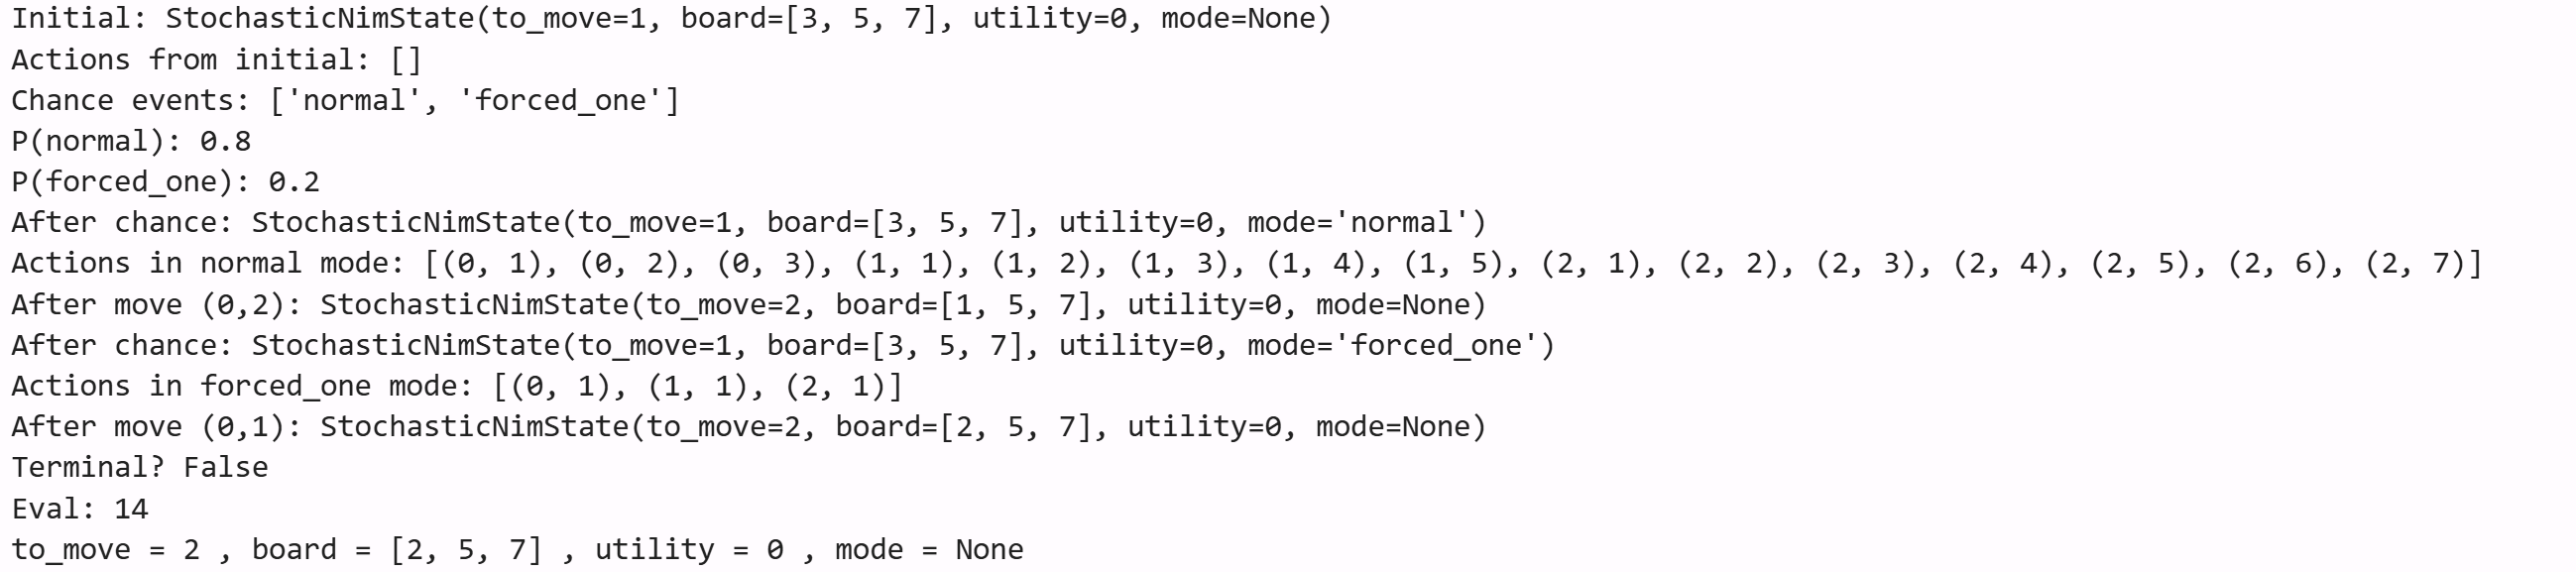

## Required Test Execution (Stochastic / Expectimax)

You must test your stochastic Nim implementation using the following test cases.



### Test Cases

```python
tests_expectimax = [
    ([1,1], 'exp', 'random'),
    ([2,2], 'exp', 'random'),
    ([1,2,3], 'exp', 'random'),
    ([1,3,5], 'exp', 'random'),
    ([3,4,5], 'exp', 'random'),
    ([1,3,5,7], 'exp', 'random'),
    ([2,2,2], 'exp', 'exp'),
    ([1,1,1,1], 'exp', 'exp')
]


## Step 3: Analysis (6 pts)

Compare deterministic vs stochastic Nim:

- Does the strategy change?  
- Does “optimal play” still exist?  
- What did you observe from your experiments?  

**Test Run 1**
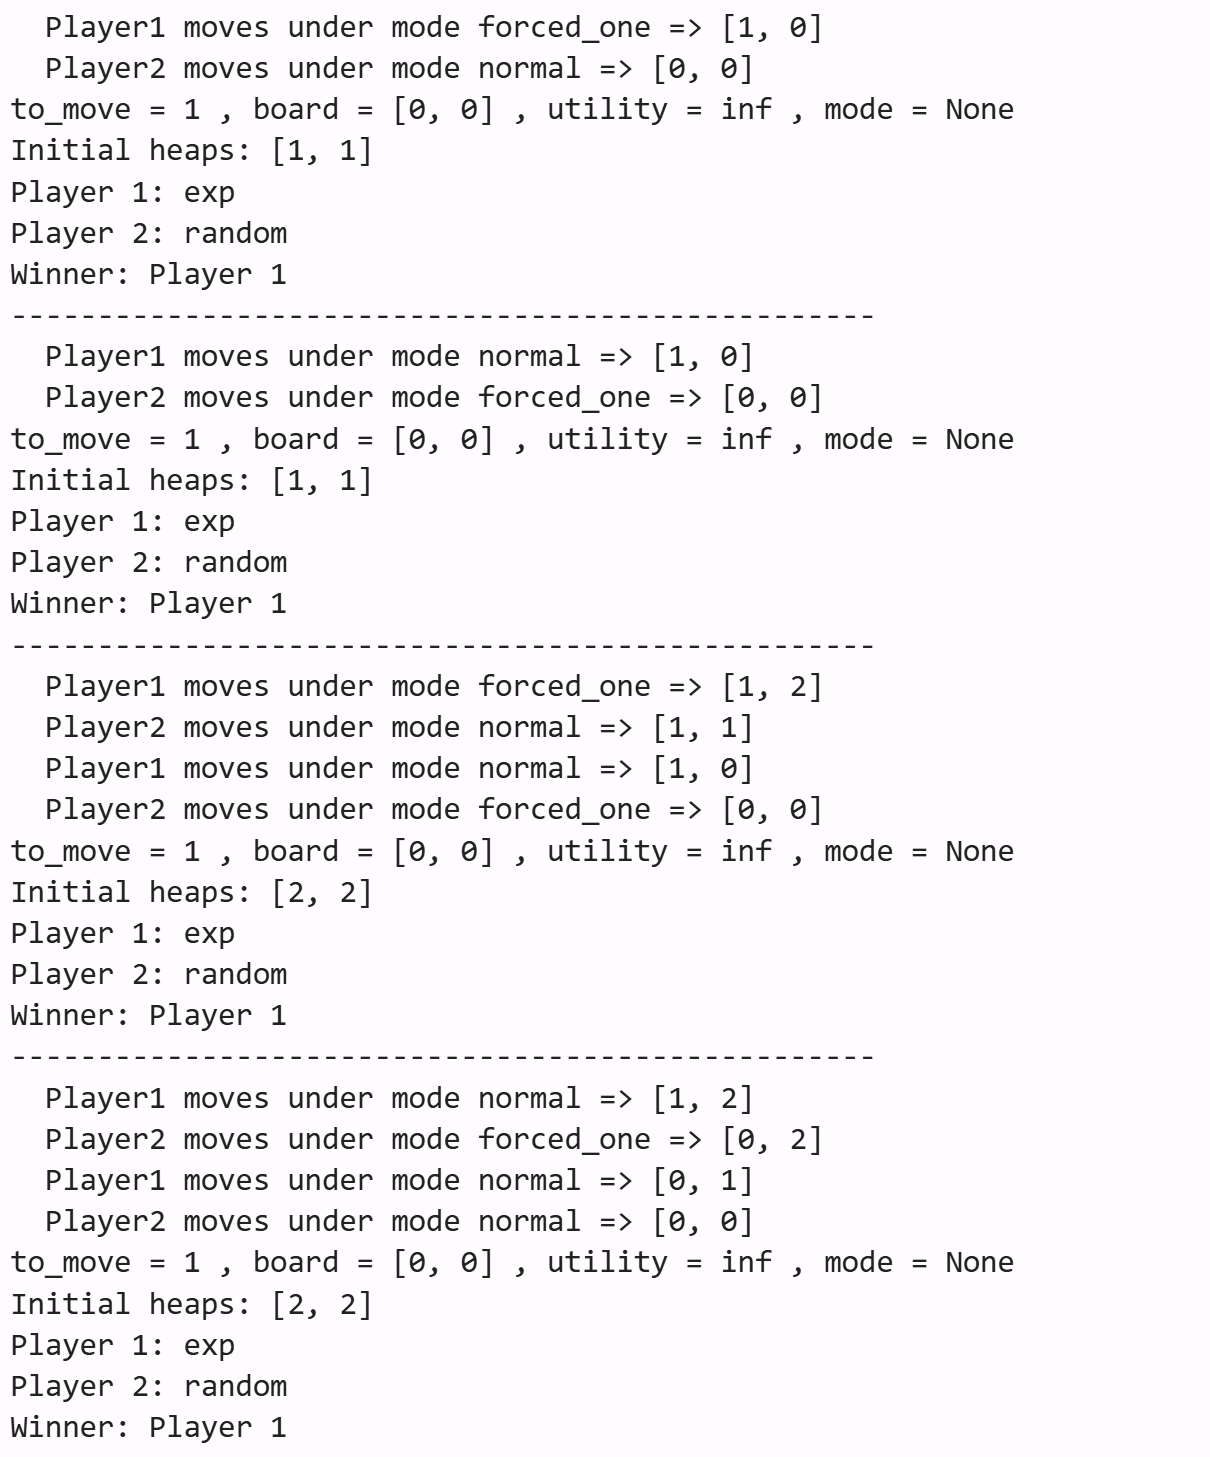

**Test Run 2**
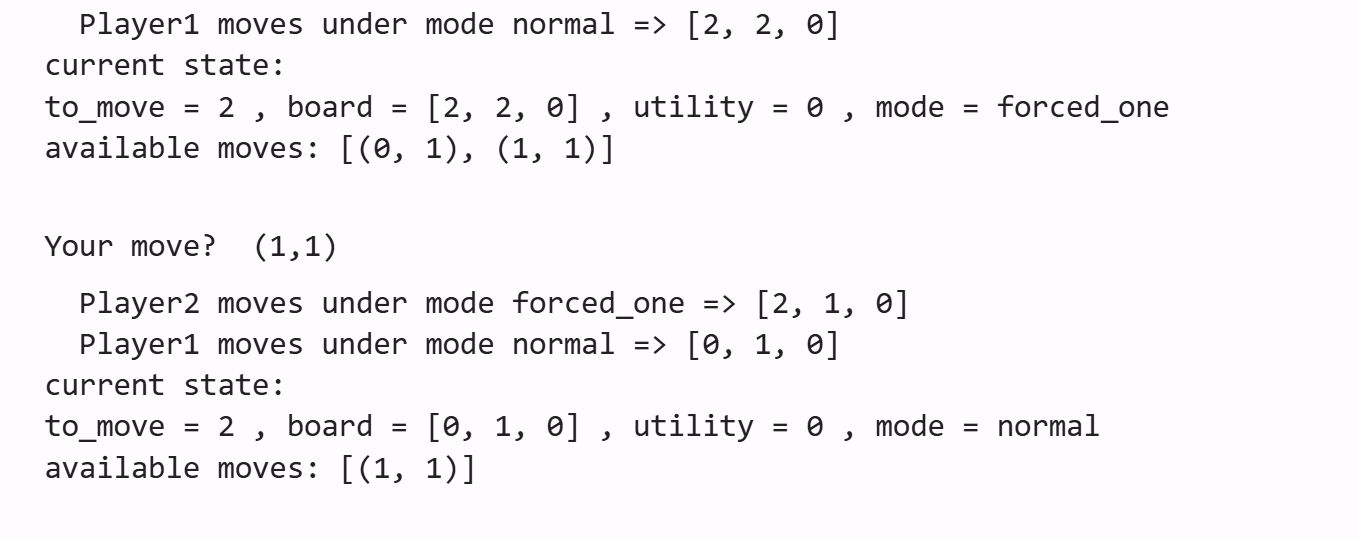
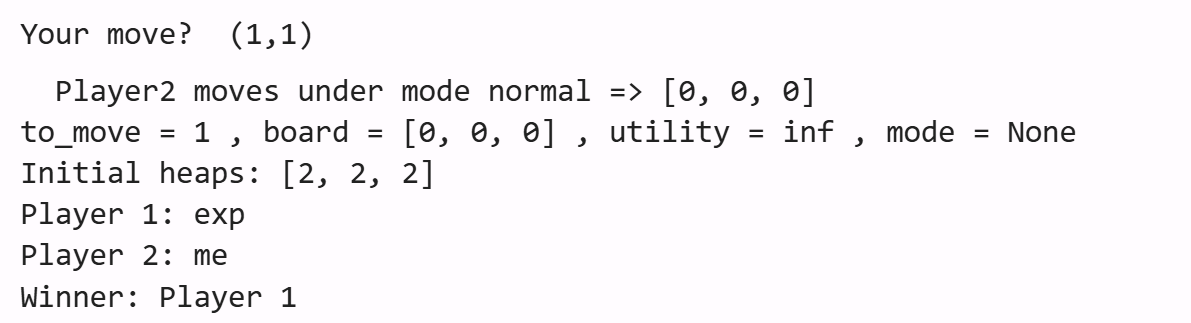

# Reflection: 

Answer briefly:
- Which algorithm was easiest to understand?  
- Which was hardest to implement?  
- What surprised you the most about adversarial search?  

# Written Part

# 1. Minimax and Alpha-Beta Pruning

## 1.1 Minimax

Figure 1.1 shows a game tree evaluated using the **minimax** algorithm.  
Squares represent **MAX** nodes, and circles represent **MIN** nodes.

Determine the move the maximizing player should take. Show the value of each non-leaf node clearly.


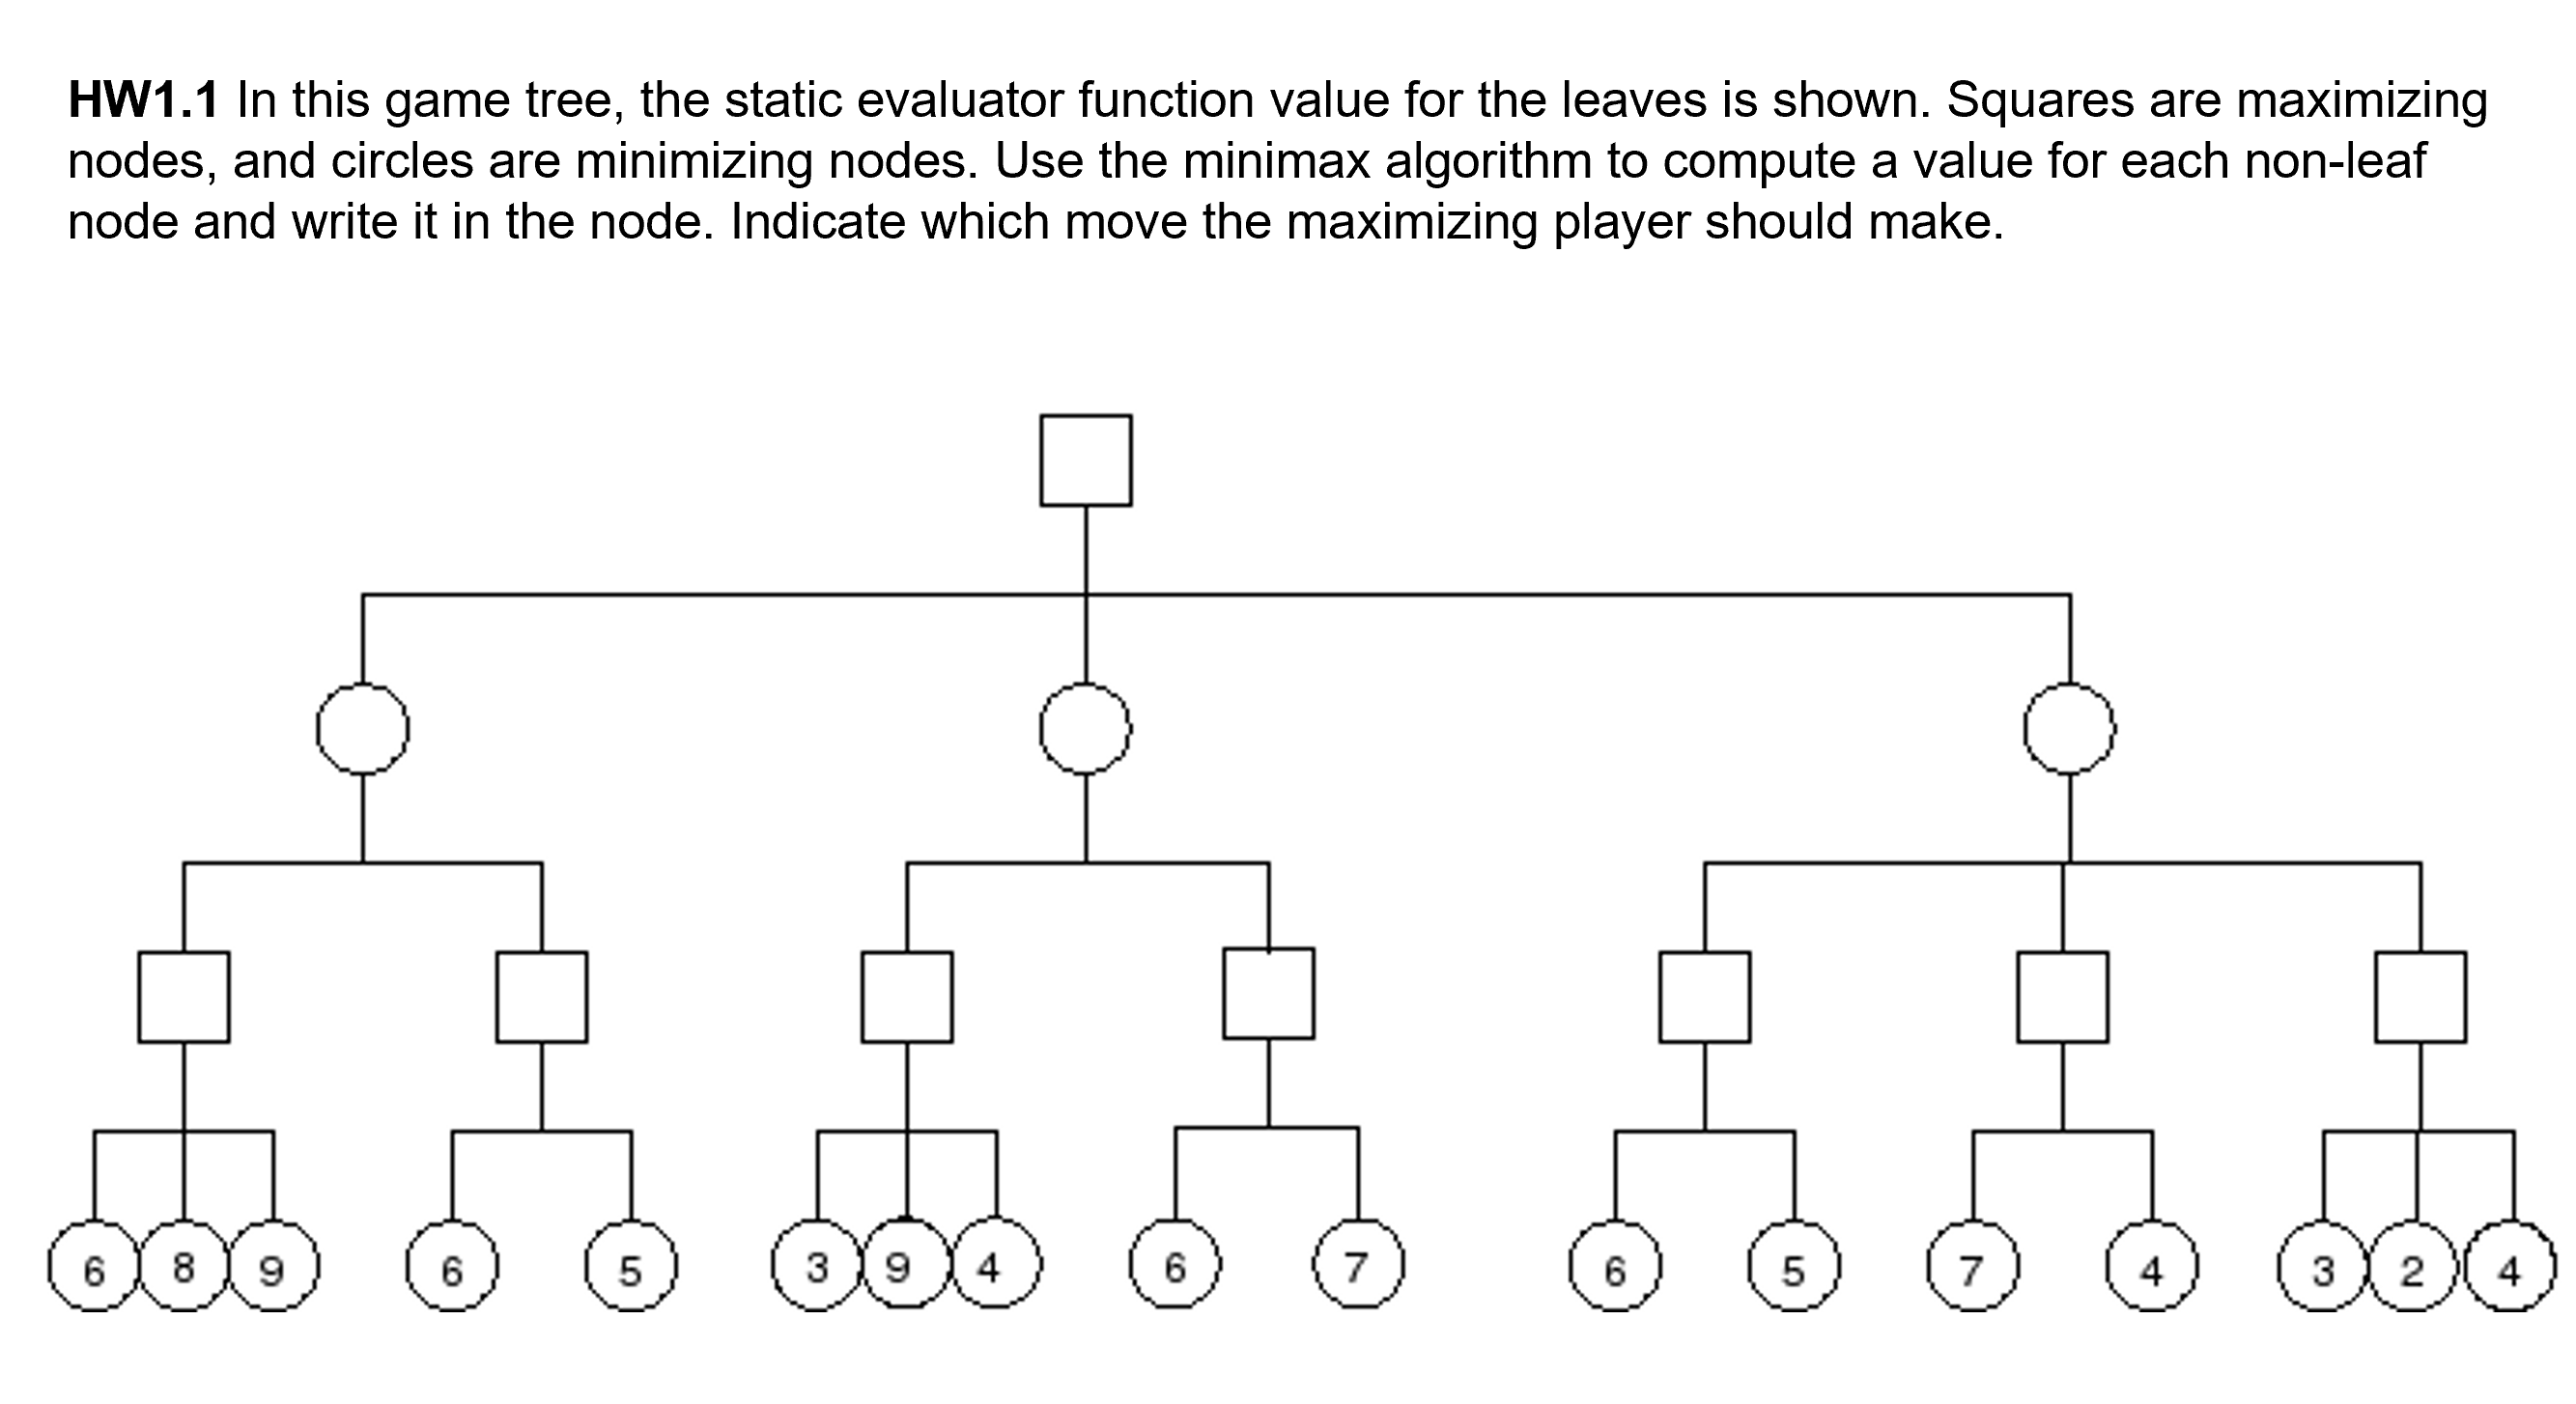


*Drag and drop your completed solution image below.*



## 1.2 Alpha-Beta Pruning

Execute the **alpha-beta pruning** algorithm on the game tree shown in Figure 1.2.

For your solution:

- cross out all **pruned nodes**
- for each non-leaf node that is **not pruned**, write either:
  - its exact final value (for example, `= 3`), or  
  - its final bound/constraint (for example, `<= 2` or `>= 8`)

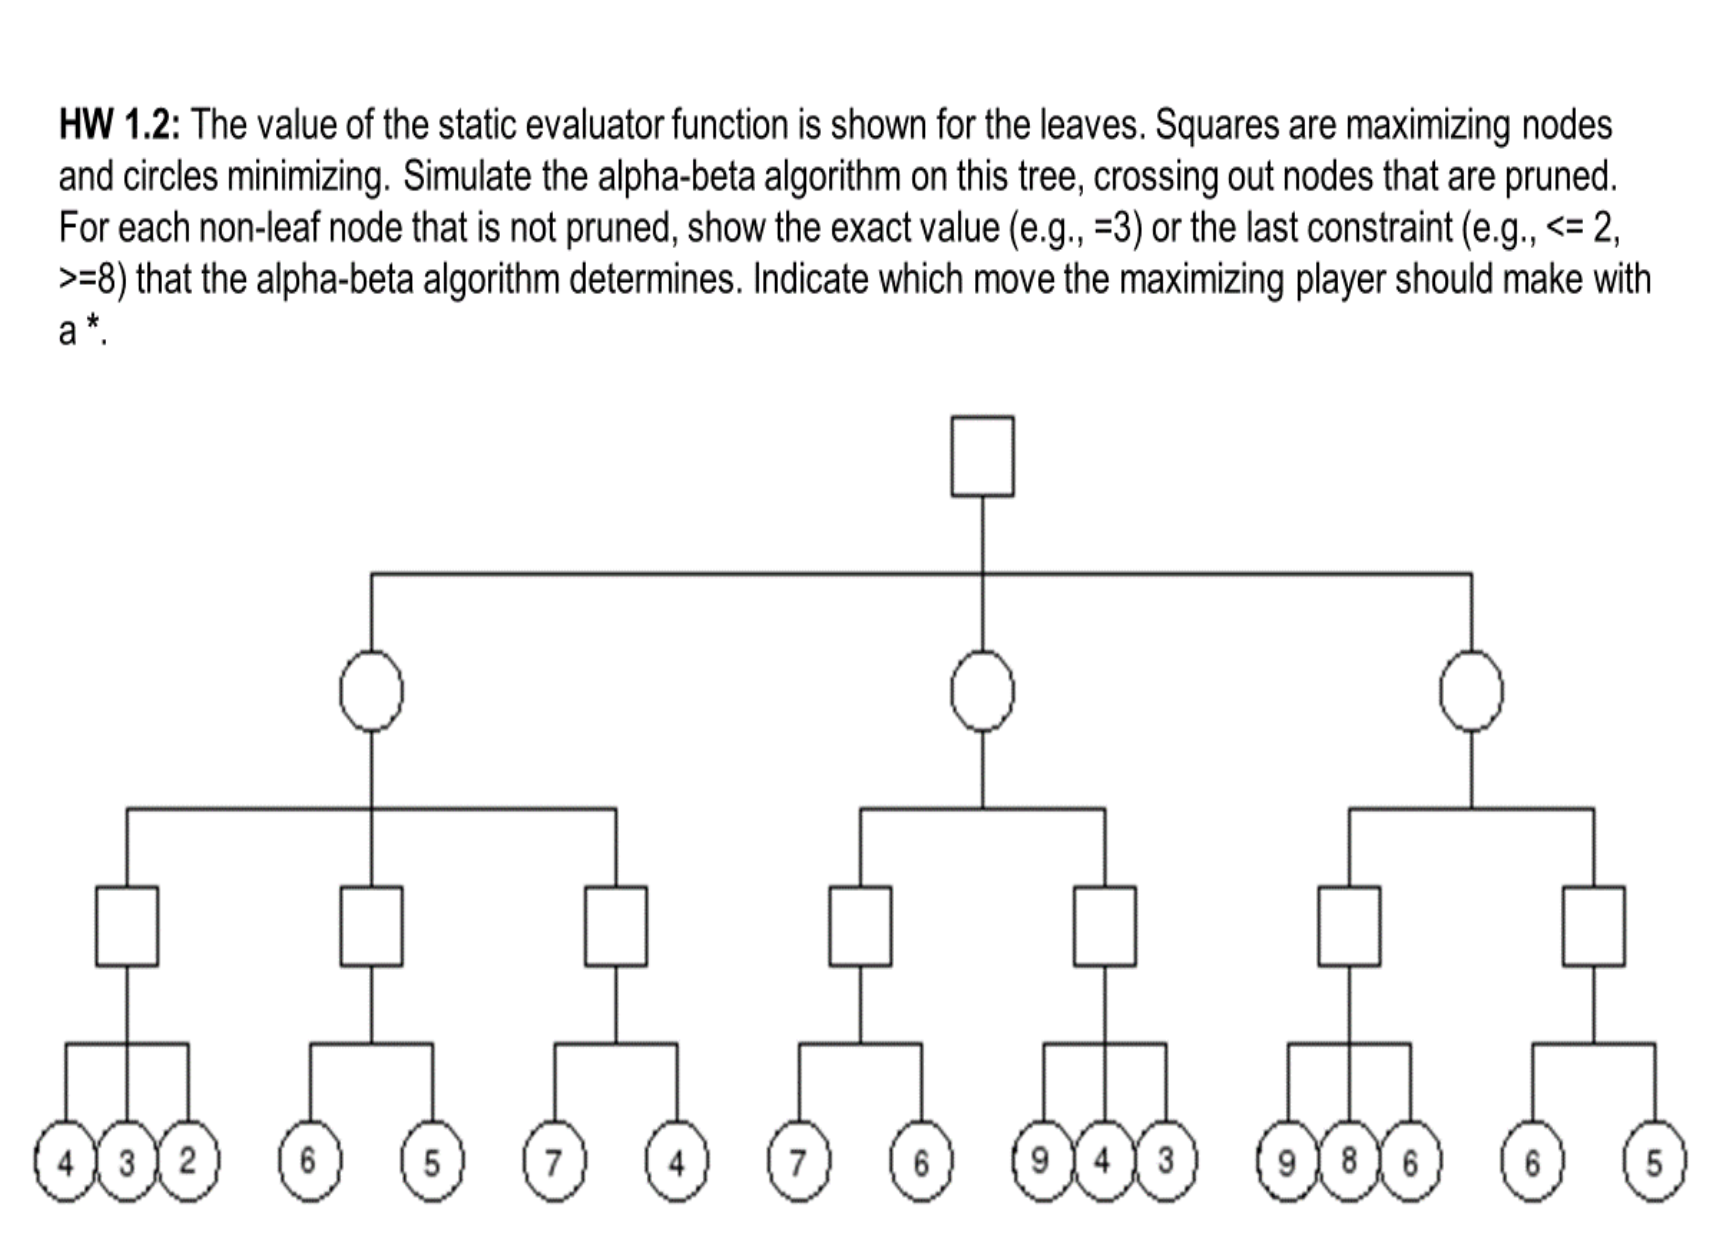'

*Drag and drop your completed solution image below.*

## 2. True / False with Justification

For each of the following statements, state whether it is **True** or **False**, and provide a short justification (about one paragraph).

### 2.1

In a fully observable, two-player, turn-taking, zero-sum game between two perfectly rational players, understanding the strategy employed by the second player—specifically, the move the second player intends to make in response to the first player's move—does not enhance the first player's outcome.

**Answer:** *Your answer here*  

**Justification:**  
*Write your justification here.*

### 2.2

In a partially observable, two-player, turn-taking, zero-sum game involving two perfectly rational players, being aware of the move the second player plans to make following the first player's move does not confer any advantage to the first player.

**Answer:** *Your answer here*  

**Justification:**  
*Write your justification here.*

### 2.3

A backgammon-playing agent possessing unlimited resources and perfect rationality never experiences defeat.

**Answer:** *Your answer here*  

**Justification:**  
*Write your justification here.*

# 3. Respond to the following questions about the NIM game (Misère Nim).

  
  Note: In **Misère Nim**, the player who removes the last object **loses**.

### 3.1
For a NIM game with initial configuration `[3, 5, 7]`, what is the **shortest possible game** in terms of plys?

*Your answer here.*



### 3.2
For a NIM game with initial configuration `[3, 5, 7]`, what is the **longest possible game** in terms of plys?

*Your answer here.*



### 3.3
For a NIM game with initial configuration `[H1, H2, ..., Hn]`, where each `Hi` is a positive integer and `n > 0`, what is the **initial branching factor** of the game tree? In other words, how many legal moves are available from the initial state?

*Your answer here.*



### 3.4
For a NIM game with initial configuration `[H1, H2, ..., Hn]`, where each `Hi` is a positive integer and `n > 0`, what is the **shortest possible game** in terms of plys?

*Your answer here.*



### 3.5
For a NIM game with initial configuration `[H1, H2, ..., Hn]`, where each `Hi` is a positive integer and `n > 0`, what is the **longest possible game** in terms of plys?

*Your answer here.*

### 3.6
Does the change from standard Nim to Misère Nim affect:
- the branching factor?
- the shortest or longest possible game?

*Your answer here.*
